# Эксперименты для улучшения качества работы GRU


**Содержание:**
- [Группировка классов](#группировка-классов)
- [Class weights](#cross-entropy--class-weights)
- [Weighted Random Sampler](#sampler)
- [Focal Loss](#focal-loss)
- [Выводы](#выводы-и-наблюдения)

In [1]:
import pandas as pd
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from utils import plot_train_dynamics, create_sequences
from attention_gru import DetectorAttentionGRU

In [2]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Группировка классов

In [4]:
data = pd.read_csv('Free_Text_EmoSurv.csv')

Исходные классы:

- `0`: Angry
- `1`: Calm
- `2`: Happy
- `3`: Neutral
- `4`: Sad

In [5]:
emotion_mapping = {
    0: 2,  # Angry -> Negative
    1: 1,  # Calm -> Positive
    2: 1,  # Happy -> Positive
    3: 0,  # Neutral -> Neutral
    4: 2   # Sad -> Negative
}

data['emotionIndex'] = data['emotionIndex'].map(emotion_mapping)

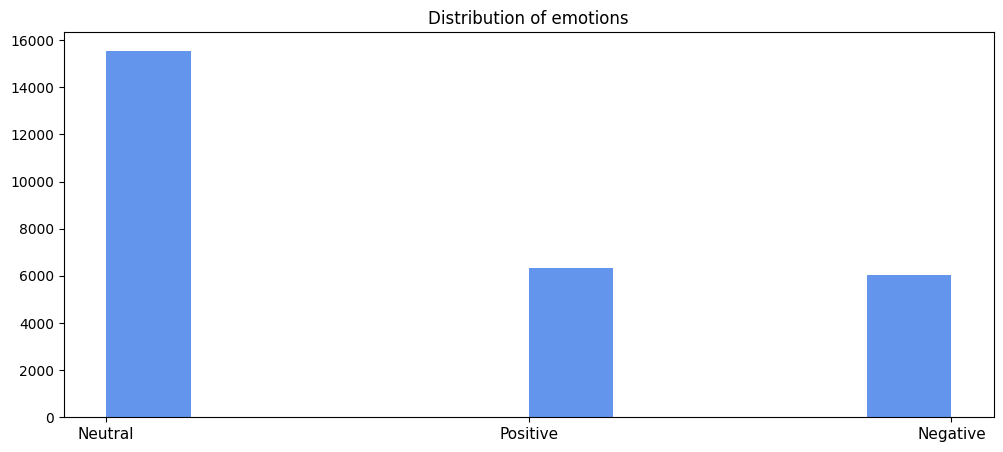

In [6]:
plt.figure(figsize=(12, 5))
plt.title('Distribution of emotions')
plt.hist(data['emotionIndex'], color='cornflowerblue')
plt.xticks([0, 1, 2], ['Neutral', 'Positive', 'Negative'],fontsize=11)
plt.show()

In [7]:
users = data['userid'].unique().tolist()
train_users, test_users = train_test_split(users, test_size = 0.3, random_state = 0) # делим на train и test по пользователям

train_data = data[data['userid'].isin(train_users)].copy()
test_data = data[data['userid'].isin(test_users)].copy()

In [8]:
test_users, valid_users = train_test_split(test_users, test_size = 0.5, random_state = 0) # дополнительно выделим валидационную выборку

test_data = data[data['userid'].isin(test_users)].copy()
valid_data = data[data['userid'].isin(valid_users)].copy()

In [9]:
feature_cols = ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter', 'hour']

scaler_X = StandardScaler()
train_data[feature_cols] = scaler_X.fit_transform(train_data[feature_cols])
test_data[feature_cols] = scaler_X.transform(test_data[feature_cols])
valid_data[feature_cols] = scaler_X.transform(valid_data[feature_cols])

In [10]:
SEQ_LEN = 32  # длина последовательности
STEP = 16     # шаг для последовательности
X_train, y_train = create_sequences(train_data, SEQ_LEN, STEP, is_train = True)
X_test, y_test = create_sequences(test_data, SEQ_LEN, STEP)
X_valid, y_valid = create_sequences(valid_data, SEQ_LEN, STEP)

## Cross Entropy + class weights + weight decay

In [11]:
# вычисляем веса для классов (обратно пропорционально частоте)
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=y_train.numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [12]:
class_weights

tensor([0.6160, 1.3652, 1.5524])

In [13]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)  
valid_loader = DataLoader(valid_dataset, batch_size = 16, shuffle = False) 
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)   

In [14]:
def model_analysis(model, total_epochs, model_optimizer, criterion, focal_loss = False):
    train_f1 = []
    train_loss = []

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        targets, predictions = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            model_optimizer.zero_grad()
            output = model(X_batch)
            
            if focal_loss == True:
                y_one_hot = F.one_hot(y_batch, num_classes=3).float() # конвертируем индексы в one-hot
                loss = criterion(output, y_one_hot)
            else:
                loss = criterion(output, y_batch)
            
            loss.backward()
            model_optimizer.step()

            preds = torch.argmax(output, dim = 1)
            total_loss += loss.item() * X_batch.size(0)
            targets.extend(y_batch.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
        
        avg_loss = total_loss / len(train_loader.dataset)
        train_loss.append(avg_loss)
        f1 = f1_score(targets, predictions, average='macro')
        train_f1.append(f1)
        
        if epoch % 10 == 9 or epoch == 0:
            print(f'Epoch {epoch+1}/{total_epochs}, Loss: {avg_loss:.6f}')
        
    return train_loss, train_f1

- Используем параметры, подобранные ранее

In [15]:
attn_model_bidirect = best_model = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 1,  num_classes = 3, dropout = 0.27, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.004, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight = class_weights)

In [16]:
train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 40, optimizer, criterion)

Epoch 1/40, Loss: 1.083777
Epoch 10/40, Loss: 1.004698
Epoch 20/40, Loss: 0.978918
Epoch 30/40, Loss: 0.914896
Epoch 40/40, Loss: 0.826802


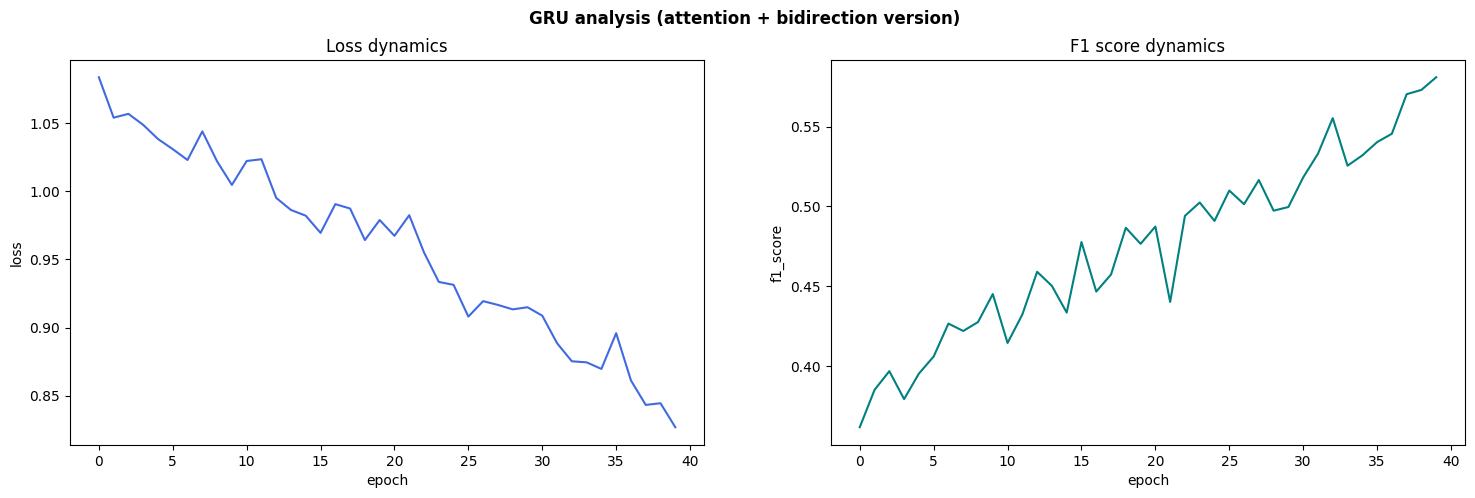

In [17]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

Как можем заметить, улучшения есть, но переобучение очень сильное

**macro F1:** $\quad 0.17 \longrightarrow 0.32 \: \: (+ 15\%)$

In [18]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.43      0.29      0.34        63
    Positive       0.35      0.20      0.25        45
    Negative       0.14      0.36      0.20        25

    accuracy                           0.27       133
   macro avg       0.30      0.28      0.27       133
weighted avg       0.35      0.27      0.29       133



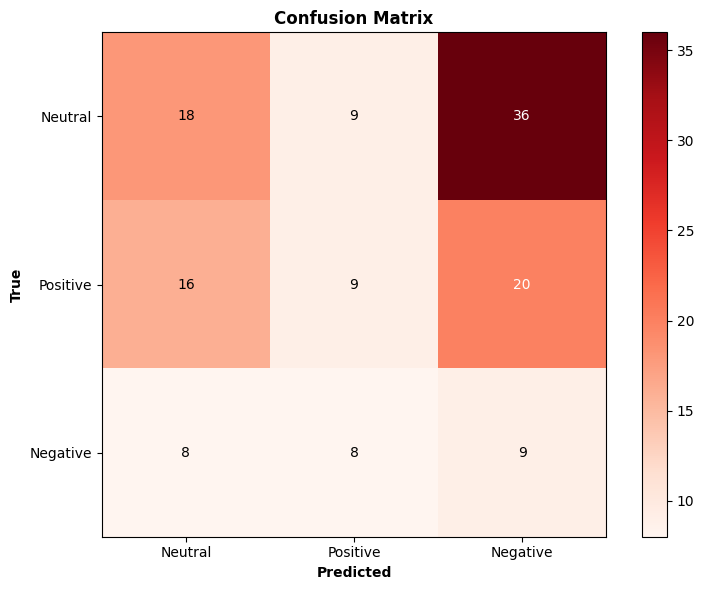

In [19]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

- Модель все еще "боится" ошибаться на редком классе (большая часть предскзаний - негативный класс)
- Позитивный и нейтральный классы плохо распознаются

## Sampler

#### С возвращением

In [20]:
train_labels = torch.tensor([y for _, y in train_dataset])
class_counts = torch.bincount(train_labels)

# веса для каждого обучающего примера
class_weights = len(train_labels) / (3 * class_counts.float())
sample_weights = class_weights[train_labels] 

In [21]:
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=sample_weights,  # веса для каждого примера
    num_samples=len(sample_weights),  # сколько примеров выбрать за эпоху
    replacement=True  # можно ли выбирать один пример несколько раз
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    sampler = sampler
)

In [22]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 1,  num_classes = 3, dropout = 0.27, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.004, weight_decay = 1e-4)
criterion = nn.CrossEntropyLoss()

In [23]:
train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 40, optimizer, criterion)

Epoch 1/40, Loss: 1.065554
Epoch 10/40, Loss: 1.011807
Epoch 20/40, Loss: 0.953076
Epoch 30/40, Loss: 0.934160
Epoch 40/40, Loss: 0.870737


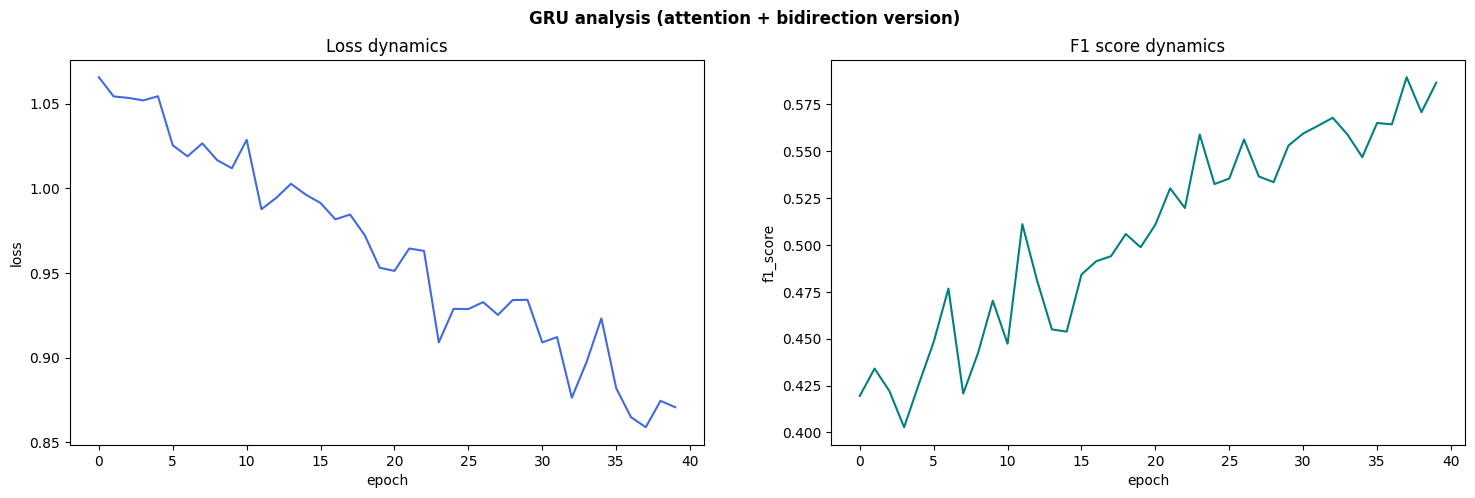

In [24]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

- Незначительные улучшения по точности и F1 macro (+1 %)
- Видно сильное переобучение 

In [25]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.53      0.29      0.37        63
    Positive       0.41      0.27      0.32        45
    Negative       0.21      0.60      0.32        25

    accuracy                           0.34       133
   macro avg       0.39      0.38      0.34       133
weighted avg       0.43      0.34      0.34       133



### Без возвращения


In [26]:
sampler = WeightedRandomSampler(
    weights=sample_weights,  # веса для каждого примера
    num_samples=len(sample_weights),  # сколько примеров выбрать за эпоху
    replacement=False  # можно ли выбирать один пример несколько раз
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    sampler = sampler
)

In [27]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 1,  num_classes = 3, dropout = 0.27, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.004, weight_decay = 1e-4)
criterion = nn.CrossEntropyLoss()

In [28]:
train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 40, optimizer, criterion)

Epoch 1/40, Loss: 0.981319
Epoch 10/40, Loss: 0.953361
Epoch 20/40, Loss: 0.925645
Epoch 30/40, Loss: 0.875737
Epoch 40/40, Loss: 0.818772


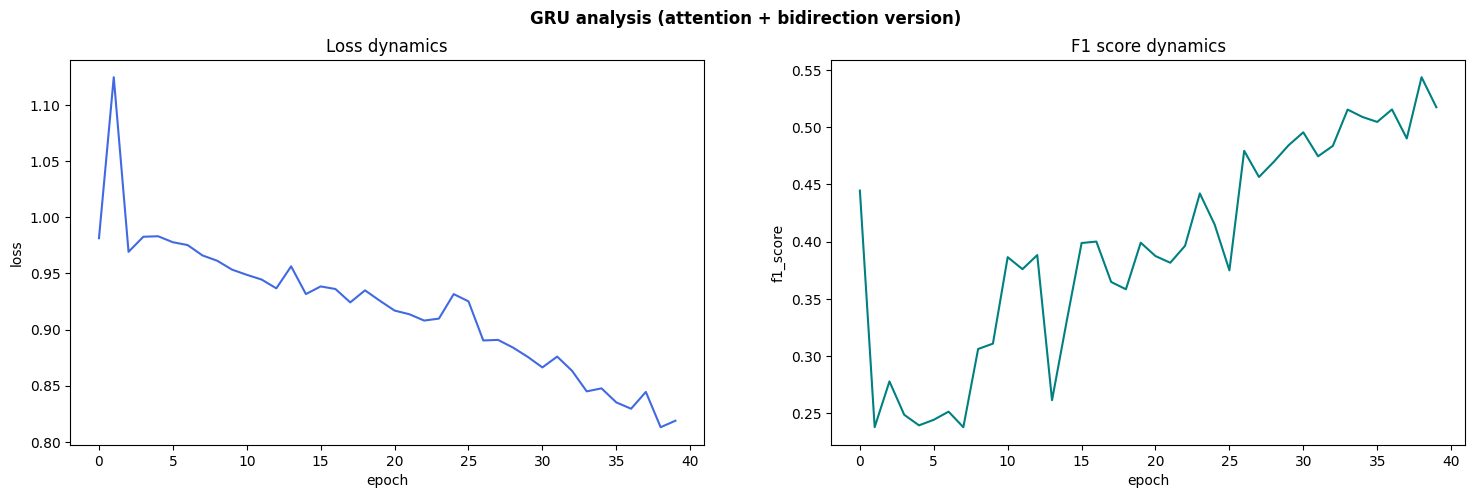

In [29]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

- Все еще сильное переобучение, однако лучший за все время результат по точности (44 %)
- Больше всего страдает класс Positive - очень низкие recall и f1 (почти 0)

In [30]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.46      0.81      0.59        63
    Positive       0.25      0.04      0.08        45
    Negative       0.07      0.04      0.05        25

    accuracy                           0.41       133
   macro avg       0.26      0.30      0.24       133
weighted avg       0.32      0.41      0.31       133



- Попробуем уменьшить количество эпох

In [31]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 1,  num_classes = 3, dropout = 0.27, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.004, weight_decay = 1e-4)
criterion = nn.CrossEntropyLoss()

train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 30, optimizer, criterion)

Epoch 1/30, Loss: 0.969294
Epoch 10/30, Loss: 0.949489
Epoch 20/30, Loss: 0.899115
Epoch 30/30, Loss: 0.846909


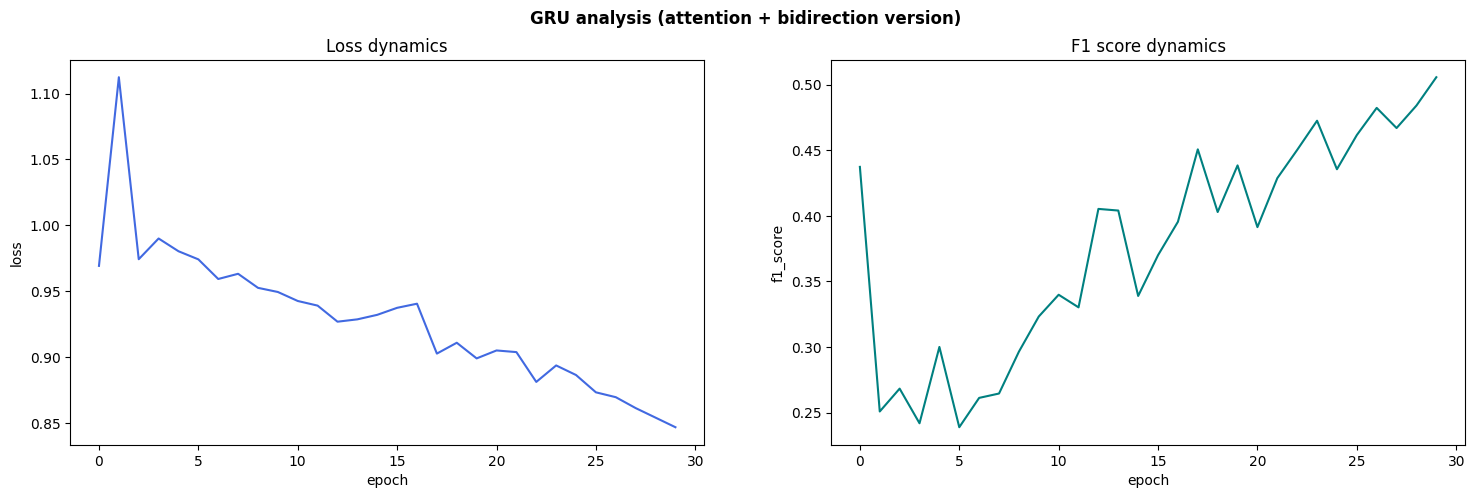

In [32]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

In [33]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.43      0.71      0.54        63
    Positive       0.00      0.00      0.00        45
    Negative       0.04      0.04      0.04        25

    accuracy                           0.35       133
   macro avg       0.16      0.25      0.19       133
weighted avg       0.21      0.35      0.26       133



## Focal Loss

> Focal Loss —  функция потерь для решения проблемы сильного дисбаланса классов


- Модификация стандартного расчета функции потерь с целью снижения веса простых примеров. Это заставляет алгоритм оптимизации сосредоточить свою обучающую способность на сложных (трудноклассифицируемых) примерах, которые критически важны для производительности модели

- **Идея:** вводится коэффициент $\alpha$, который уменьшает вклад в потери по мере роста уверенности в правильном классе. Веса модели обновляются преимущественно на основе неверно классифицированных образцов или тех, в которых модель не уверена

<img src="imgs/focal_loss.jpeg" width="25%"/>

In [34]:
class FocalLoss(nn.Module):
    def __init__(self, alpha = 0.25, gamma = 2.0, reduction = 'mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: [batch_size, num_classes]
        # targets: [batch_size, num_classes] - one-hot encoded
        probs = F.softmax(inputs, dim=1)
        
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # pt - вероятность правильного класса
        pt = torch.sum(probs * targets, dim=1)  
        
        focal_weight = (1 - pt) ** self.gamma
        
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            alpha_t = torch.sum(alpha_t * targets, dim=1) 
            focal_weight = alpha_t * focal_weight
        
        focal_loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [35]:
attn_model_bidirect_f = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 1,  num_classes = 3, dropout = 0.27, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect_f.parameters(), lr = 0.004)
criterion_focal = FocalLoss(alpha = 0.25) 

train_loss_attn_bf, train_f1_attn_bf = model_analysis(attn_model_bidirect_f, 40, optimizer, criterion_focal, focal_loss = True)

Epoch 1/40, Loss: 0.105110
Epoch 10/40, Loss: 0.098245
Epoch 20/40, Loss: 0.093906
Epoch 30/40, Loss: 0.085146
Epoch 40/40, Loss: 0.074614


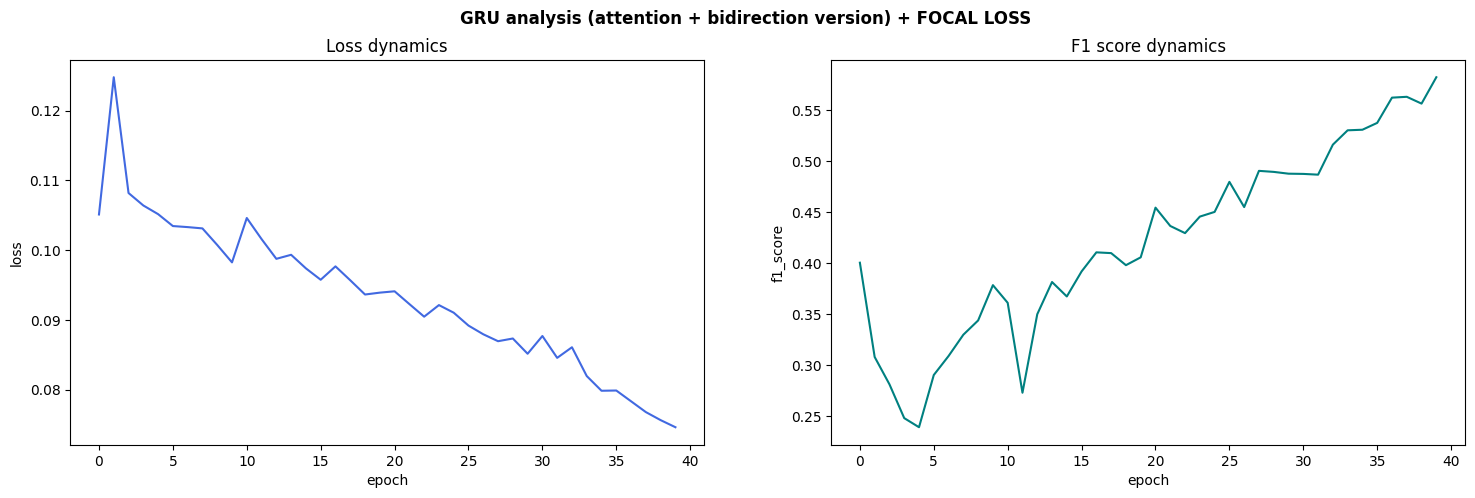

In [36]:
fig = plot_train_dynamics(attn_model_bidirect_f, train_loss_attn_bf, train_f1_attn_bf, 'GRU analysis (attention + bidirection version) + FOCAL LOSS')
plt.show(fig)

In [37]:
pred = attn_model_bidirect_f(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.46      0.84      0.59        63
    Positive       0.33      0.07      0.11        45
    Negative       0.25      0.08      0.12        25

    accuracy                           0.44       133
   macro avg       0.35      0.33      0.27       133
weighted avg       0.38      0.44      0.34       133



In [38]:
def validate(model, val_loader):
    model.eval()  # режим оценки (выключаем dropout, batch norm)
    all_preds = []
    all_targets = []
    
    with torch.no_grad(): 
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)  
            preds = torch.argmax(output, dim = 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    
    f1 = f1_score(all_targets, all_preds, average='macro')
    return f1

In [39]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 1)

    model = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 1,  num_classes = 3, dropout = 0.27, bidirectional = True).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr = 0.004)
    criterion_focal = FocalLoss(alpha = alpha) 

    # обучаем с ранней остановкой 
    best_val_f1 = 0
    patience_counter = 0

    for epoch in range(30):
        model.train()
        for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                y_one_hot = F.one_hot(y_batch, num_classes=3).float() # конвертируем индексы в one-hot
        
                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_one_hot)
                loss.backward()
                optimizer.step()
        
        # валидируем на каждой эпохе
        val_f1 = validate(model, valid_loader)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 4:
                break

    return best_val_f1


study = optuna.create_study(direction='maximize', study_name='FocalLoss_hyperparametrs')
optuna.logging.disable_default_handler()
study.optimize(objective, n_trials = 50)

trial = study.best_trial

print("Best F1 score: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

[I 2026-06-29 23:28:00,118] A new study created in memory with name: FocalLoss_hyperparametrs


Best F1 score: 0.3038310708898944
Best hyperparameters: {'alpha': 0.8902786314385547}


In [40]:
attn_model_bidirect_f = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 1,  num_classes = 3, dropout = 0.27, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect_f.parameters(), lr = 0.004)
criterion_focal = FocalLoss(**trial.params) 

train_loss_attn_bf, train_f1_attn_bf = model_analysis(attn_model_bidirect_f, 40, optimizer, criterion_focal, focal_loss = True)

Epoch 1/40, Loss: 0.379468
Epoch 10/40, Loss: 0.362994
Epoch 20/40, Loss: 0.342677
Epoch 30/40, Loss: 0.308394
Epoch 40/40, Loss: 0.249435


In [41]:
pred = attn_model_bidirect_f(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.46      0.60      0.52        63
    Positive       0.00      0.00      0.00        45
    Negative       0.17      0.32      0.22        25

    accuracy                           0.35       133
   macro avg       0.21      0.31      0.25       133
weighted avg       0.25      0.35      0.29       133



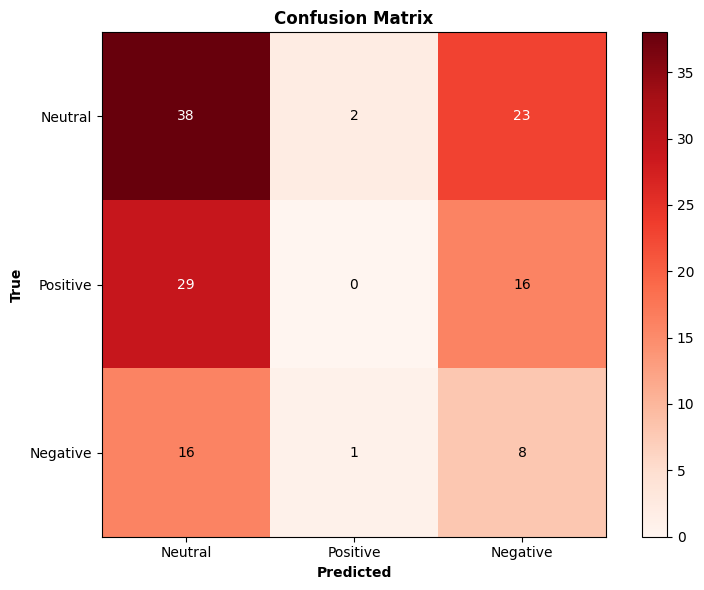

In [42]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

## Выводы и наблюдения

**Cross Entropy + class weights + weight decay**
- Модель "боится" ошибаться на редких классах (Negative), поэтому часто жертвует Positive и Neutral ради Negative. Это видно по матрице ошибок

**Sampler**
- Sampler оказался слишком агрессивным для борьбы с дисбалансом классов. Искусственное увеличение количества примеров редкого класса (Negative) путем их повторения заставляет модель "запоминать" эти конкретные примеры, а не обобщать

**Focal Loss**
- Результат обучения с Focal Loss: F1 (macro) = 0.34, Accuracy = 37%. Это лучшая точность, но переобучение все еще сильное
- Решить проблему с редким классом (Negative) не удалось. Вместо самого частого класса модель предсказывает именно Negative, а так же сильно путает Neutral и Positive